# Import header

In [2]:
import os
import random
import shutil
import cv2
import time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sn
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from PIL import Image
from tqdm import tqdm
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import TopKCategoricalAccuracy
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.applications import InceptionResNetV2
from tensorflow.keras import regularizers
from keras.preprocessing.image import img_to_array
from sklearn.metrics import confusion_matrix
from sklearn.metrics import average_precision_score

# 測試是否讀取到圖片

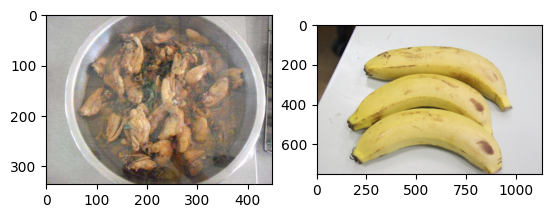

In [3]:
plt.figure();
test_path1 = '/kaggle/input/all-data/all_data/三杯雞/8039.jpg'
plt.subplot(121)
img1 = cv2.imread(test_path1)
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
plt.imshow(img1)
test_path2 = '/kaggle/input/all-data/all_data/香蕉/1550.gif'
plt.subplot(122)
img2 = Image.open(test_path2)
img2 = img2.convert('RGB')
img2 = np.array(img2)
plt.imshow(img2)
plt.show()

# 將所有 <圖片路徑,圖片類別> 讀到data

In [4]:
dataset_dir = '/kaggle/input/all-data/all_data'
file_info = []
label_map = {}
class_counter = 0

# 遍歷所有類別目錄
for class_name in os.listdir(dataset_dir):
    class_path = os.path.join(dataset_dir, class_name)
    if os.path.isdir(class_path):  # 若為子目錄 e.g. all_data/香蕉/
        if class_name not in label_map:
            label_map[class_name] = class_counter
            class_counter += 1
        img_cnt  = 0
        for img_file in os.listdir(class_path):
            img_path = os.path.join(class_path, img_file)
            file_info.append((img_path, class_name))
            img_cnt += 1
            # if (img_cnt >= 10): # 小資料測試
            #     break

print(file_info[0])
print(len(file_info))
print(label_map)
print(len(label_map))

('/kaggle/input/all-data/all_data/有機小松菜/7981.jpg', '有機小松菜')
105402
{'有機小松菜': 0, '鹽酥雞': 1, '空心菜': 2, '青江菜': 3, '棗子': 4, '什錦炒麵': 5, '咖哩雞': 6, '滷雞腿': 7, '馬鈴薯燉肉': 8, '糖醋雞丁': 9, '客家小炒': 10, '香蕉': 11, '香酥魚排': 12, '木瓜': 13, '關東煮': 14, '蓮霧': 15, '義大利麵': 16, '麻油雞': 17, '有機青松菜': 18, '大陸妹': 19, '小番茄': 20, '黑胡椒豬柳': 21, '油菜': 22, '豆芽菜': 23, '螞蟻上樹': 24, '鳳梨': 25, '沙茶肉片': 26, '麻婆豆腐': 27, '白菜滷': 28, '福山萵苣': 29, '紅蘿蔔炒蛋': 30, '菠菜': 31, '柳丁': 32, '洋蔥炒蛋': 33, '塔香海茸': 34, '高麗菜': 35, '芥藍菜': 36, '西瓜': 37, '麥克雞塊': 38, '蒸蛋': 39, '番茄炒蛋': 40, '橘子': 41, '玉米炒蛋': 42, '滷蛋': 43, '瓜仔肉': 44, '鵝白菜': 45, '白米飯': 46, '三杯雞': 47, '葡萄': 48, '蒜泥白肉': 49}
50


# 打亂檔案順序

In [5]:
file_info = np.array(file_info)
idx = np.arange(len(file_info))
np.random.shuffle(idx)
file_info = file_info[idx]
for i in range(10):
    print(file_info[i])

['/kaggle/input/all-data/all_data/三杯雞/13684.jpg' '三杯雞']
['/kaggle/input/all-data/all_data/青江菜/4916.jpg' '青江菜']
['/kaggle/input/all-data/all_data/關東煮/24454.jpg' '關東煮']
['/kaggle/input/all-data/all_data/客家小炒/20733.jpg' '客家小炒']
['/kaggle/input/all-data/all_data/螞蟻上樹/6723.jpg' '螞蟻上樹']
['/kaggle/input/all-data/all_data/葡萄/22229.jpg' '葡萄']
['/kaggle/input/all-data/all_data/蒜泥白肉/28666.jpg' '蒜泥白肉']
['/kaggle/input/all-data/all_data/紅蘿蔔炒蛋/23829.jpg' '紅蘿蔔炒蛋']
['/kaggle/input/all-data/all_data/義大利麵/65657.jpg' '義大利麵']
['/kaggle/input/all-data/all_data/紅蘿蔔炒蛋/23730.jpg' '紅蘿蔔炒蛋']


# 定義資料比例

In [6]:
train_ratio = 0.7
valid_ratio = 0.1
test_ratio = 0.2

train_size = int(len(file_info) * train_ratio)
valid_size = int(len(file_info) * valid_ratio)
test_size = len(file_info) - train_size - valid_size

print(f"train_size: {train_size}")
print(f"valid_size: {valid_size}")
print(f"test_size: {test_size}")

train_size: 73781
valid_size: 10540
test_size: 21081


# 定義data_generator，動態產生資料供模型訓練、推論

In [8]:
def data_generator(file_info, label_map, batch_size, img_size, num_classes):
    total_files = len(file_info)
    while True:
        for start_idx in range(0, total_files, batch_size):
            # 確認當前 batch 處理的 file_info範圍
            batch_data = np.empty((batch_size, *img_size, 3))
            batch_labels = []
            end_idx = min(start_idx + batch_size, total_files)
            
            # 實際讀取檔案
            for i, (img_path, img_label) in (enumerate(file_info[start_idx:end_idx])):
                img = None
                if img_path.endswith('.gif'):
                    img = Image.open(img_path)
                    img = img.convert('RGB')
                    img = np.array(img)
                else:
                    img = cv2.imread(img_path)  
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                
                img = cv2.resize(img, img_size)
                batch_data[i] = img
                
                label_idx = label_map[img_label]
                one_hot_label = np.zeros(num_classes)
                one_hot_label[label_idx] = 1
                batch_labels.append(one_hot_label)

            batch_labels = np.array(batch_labels)
            yield batch_data[:i+1], batch_labels

# 建立 base model

In [9]:
# EfficientNet
weights_path = '/kaggle/input/efficientnetb0-notop-h5/efficientnetb0_notop.h5'

base_model = tf.keras.applications.EfficientNetB0(
    weights=None,
    input_shape=(224, 224, 3),
    include_top=False
)

base_model.load_weights(weights_path)
base_model.trainable = True

In [ ]:
# ResNet50
# weights_path = '/kaggle/input/resnet50/tensorflow2/default/1/resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5'

# base_model = tf.keras.applications.ResNet50(
#     weights=None,
#     input_shape=(224, 224, 3),
#     include_top=False
# )

# base_model.load_weights(weights_path)
# base_model.trainable = True

# 透過 base model 進行 transfer learning，建立完整 model

In [10]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5),
    layers.Dense(50, activation='softmax', kernel_regularizer=regularizers.l2(0.1))
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.TopKCategoricalAccuracy(k=5, name='top-5-accuracy')
    ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ ?                      │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │   0 (unbuilt) │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 4,007,548 (15.29 MB)

 Non-trainable params: 42,023 (164.16 KB)

# 訓練模型

#### 備註：由於我最後一次 train 的 model 並不是表現最好的 model，所以目前 notebook 中，殘留的 output 並非最好的模型表現。最好的模型表現紀錄於 PPT 的實驗結果分析章節，還請以 PPT 的模型為基準，感謝。

In [11]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5,
    patience=3,
    min_lr=5e-5
)

train_gen = data_generator(file_info[:train_size], label_map, 32, (224, 224), 50)
valid_gen = data_generator(file_info[train_size:train_size+valid_size], label_map, 32, (224, 224), 50)

start_time = time.time()
history = model.fit(
    train_gen,
    epochs=1,
    steps_per_epoch=len(file_info[:train_size]) // 32,
    validation_data = valid_gen,
    validation_steps=len(file_info[train_size:train_size + valid_size]) // 32,
    verbose=1,
    callbacks=[reduce_lr]
)
end_time = time.time()

training_time = end_time - start_time
hours = training_time // 3600
minutes = (training_time % 3600) // 60
seconds = training_time % 60
print(f"Total training time: {int(hours)} hr {int(minutes)} min {int(seconds)} sec")

I0000 00:00:1733756200.188479     656 service.cc:145] XLA service 0x7d1120003a70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1733756200.188554     656 service.cc:153]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1733756200.188563     656 service.cc:153]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1733756247.096159     656 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2295/2305 ━━━━━━━━━━━━━━━━━━━━ 3s 340ms/step - accuracy: 0.5906 - loss: 2.4001 - top-5-accuracy: 0.8766

libpng warning: iCCP: known incorrect sRGB profile


2305/2305 ━━━━━━━━━━━━━━━━━━━━ 976s 390ms/step - accuracy: 0.5910 - loss: 2.3963 - top-5-accuracy: 0.8769 - val_accuracy: 0.7493 - val_loss: 1.1953 - val_top-5-accuracy: 0.9580 - learning_rate: 0.0010
Total training time: 0 hr 16 min 16 sec


# 印出 loss curve, accuracy curve

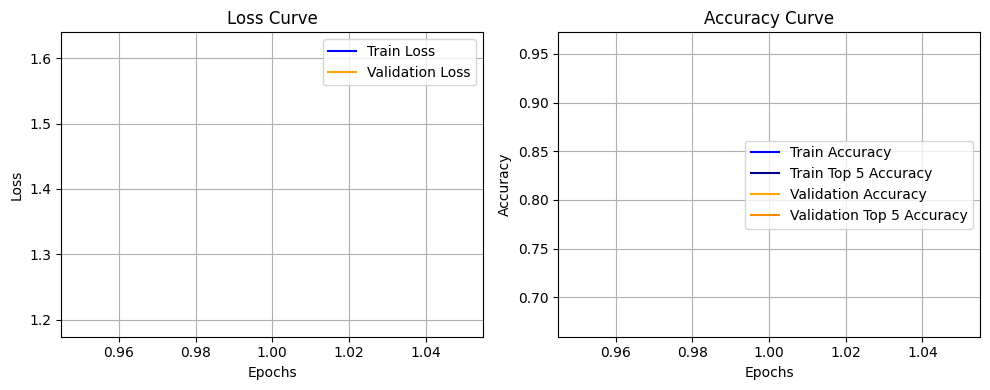

In [12]:
# 取得訓練過程的資料
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_top5_acc = history.history['top-5-accuracy']
val_top5_acc = history.history['val_top-5-accuracy']
epochs = range(1, len(train_accuracy) + 1)

# loss curve
plt.figure(figsize=(10, 4))
plt.subplot(121)
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.plot(epochs, train_loss, 'blue', label='Train Loss')
plt.plot(epochs, val_loss, 'orange', label='Validation Loss')
plt.legend()
plt.grid()

# accuracy curve
plt.subplot(122)
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.plot(epochs, train_accuracy, 'blue', label='Train Accuracy')
plt.plot(epochs, train_top5_acc, color='#00008B', label='Train Top 5 Accuracy')
plt.plot(epochs, val_accuracy, 'orange', label='Validation Accuracy')
plt.plot(epochs, val_top5_acc, color='#FF8C00', label='Validation Top 5 Accuracy')
plt.legend()
plt.grid()

plt.tight_layout()  
plt.show()

### 備註：這裡因為只 train 1 epoch，所以 curve 畫不出來

# 推論 Validation dataset

In [13]:
valid_predictions = []
valid_true_labels = []
top_1_correct = 0
top_5_correct = 0
total_samples = 0
batch_size = 32
num_batches = valid_size // batch_size + 1

with tqdm(total=num_batches, desc="Processing batches") as pbar:
    cnt = 1
    for batch_data, batch_labels in valid_gen:
        valid_prediction = model.predict(batch_data, verbose=0)

        # Top-1 acc
        predicted_label = np.argmax(valid_prediction, axis=1)
        true_label = np.argmax(batch_labels, axis=1)
        batch_correct_num = np.sum(predicted_label == true_label)
        top_1_correct += batch_correct_num
        
        # Top-5 acc
        sorted_val_pred = np.argsort(valid_prediction, axis=1)
        top_5_labels = sorted_val_pred[:, -5:]
        batch_top_5_correct_num = 0
        for i in range(len(true_label)):
            if true_label[i] in top_5_labels[i]:
                batch_top_5_correct_num += 1
        top_5_correct += batch_top_5_correct_num
        
        valid_predictions.extend(predicted_label)
        valid_true_labels.extend(true_label)
        total_samples += len(true_label)
        
        pbar.update(1)
        cnt += 1
        if cnt > num_batches:
            break

Processing batches: 100%|██████████| 330/330 [02:12<00:00,  2.49it/s]


# 計算 Top1, Top5 acc & 製作混淆矩陣 (Validation dataset)

Top-1 Accuracy: 74.94
Top-5 Accuracy: 95.80


Text(0.5, 1.0, 'Confusion Matrix (Valid Data)')

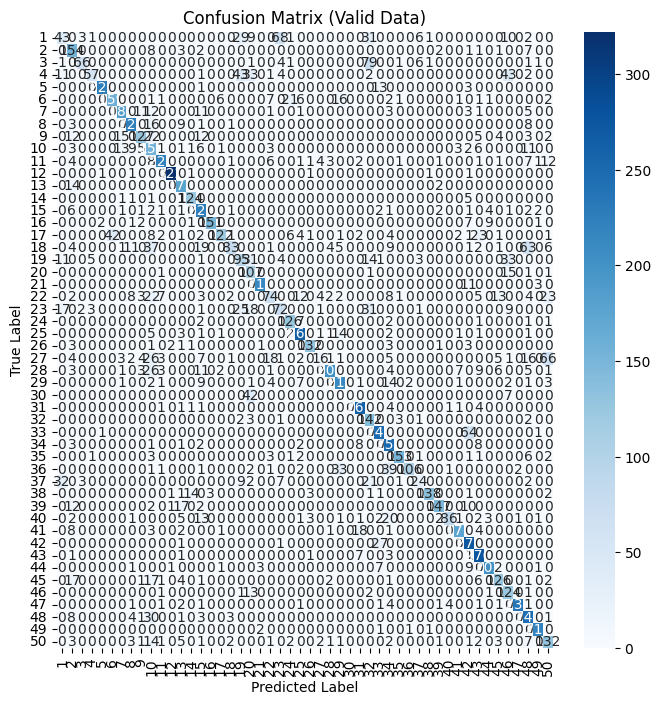

In [14]:
# Top1, Top5 acc
top_1_acc = top_1_correct / total_samples
top_5_acc = top_5_correct / total_samples
print(f"Top-1 Accuracy: {100*top_1_acc:.2f}")
print(f"Top-5 Accuracy: {100*top_5_acc:.2f}")

# 混淆矩陣
cm = confusion_matrix(valid_true_labels, valid_predictions)
class_numbers = [i + 1 for i in range(50)]
plt.figure(figsize=(8, 8))
sn.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=class_numbers,
           yticklabels=class_numbers)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Valid Data)')

# 推論 Test dataset

In [15]:
test_predictions = []
test_true_labels = []
top_1_correct = 0
top_5_correct = 0
total_samples = 0
batch_size = 32
num_batches = test_size // batch_size + 1
test_gen = data_generator(file_info[train_size+valid_size:], label_map, 32, (224, 224), 50)

with tqdm(total=num_batches, desc="Processing batches") as pbar:
    cnt = 1
    for batch_data, batch_labels in test_gen:
        test_prediction = model.predict(batch_data, verbose=0)

        # Top-1 acc
        predicted_label = np.argmax(test_prediction, axis=1)
        true_label = np.argmax(batch_labels, axis=1)
        batch_correct_num = np.sum(predicted_label == true_label)
        top_1_correct += batch_correct_num
        
        # Top-5 acc
        sorted_test_pred = np.argsort(test_prediction, axis=1)
        top_5_labels = sorted_test_pred[:, -5:]
        batch_top_5_correct_num = 0
        for i in range(len(true_label)):
            if true_label[i] in top_5_labels[i]:
                batch_top_5_correct_num += 1
        top_5_correct += batch_top_5_correct_num
        
        test_predictions.extend(predicted_label)
        test_true_labels.extend(true_label)
        total_samples += len(true_label)
        
        pbar.update(1)
        cnt += 1
        if cnt > num_batches:
            break

Processing batches: 100%|██████████| 659/659 [04:58<00:00,  2.21it/s]


# 計算 Top1, Top5 acc & 製作混淆矩陣 (Test dataset)

Top-1 Accuracy: 74.85
Top-5 Accuracy: 95.53


Text(0.5, 1.0, 'Confusion Matrix (Test Data)')

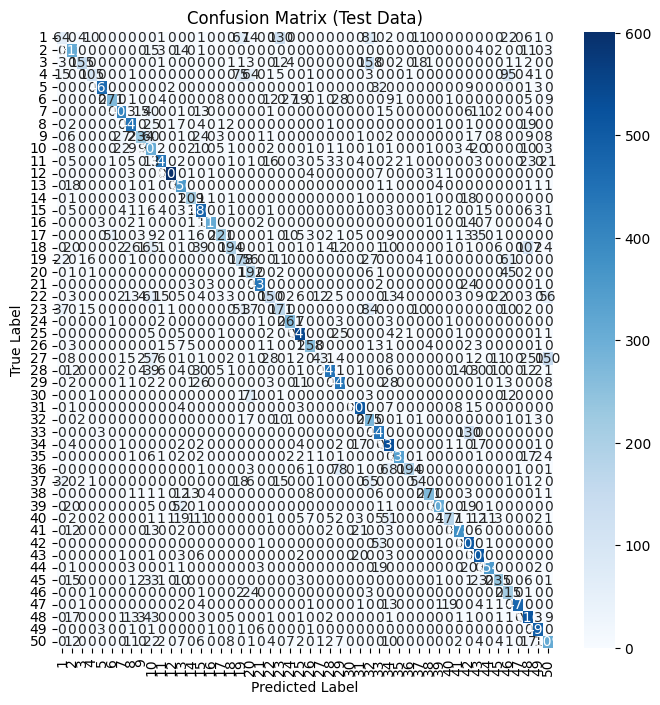

In [16]:
# Top1, Top5 acc
top_1_acc = top_1_correct / total_samples
top_5_acc = top_5_correct / total_samples
print(f"Top-1 Accuracy: {100*top_1_acc:.2f}")
print(f"Top-5 Accuracy: {100*top_5_acc:.2f}")

# 混淆矩陣
cm = confusion_matrix(test_true_labels, test_predictions)
class_numbers = [i + 1 for i in range(50)]
plt.figure(figsize=(8, 8))
sn.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=class_numbers,
           yticklabels=class_numbers)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Test Data)')

# 計算 Test dataset 的 AP、mAP

In [17]:
all_predictions = []
all_true_labels = []
num_batches = test_size // batch_size + 1
test_gen = data_generator(file_info[train_size+valid_size:], label_map, 32, (224, 224), 50)

with tqdm(total=num_batches, desc="Processing batches") as pbar:
    cnt = 1
    for batch_data, batch_labels in test_gen:
        predictions = model.predict(batch_data, verbose=0)
        all_predictions.append(predictions)
        all_true_labels.append(batch_labels)
    
        pbar.update(1)
        cnt += 1
        if cnt > num_batches:
            break

# 將資料壓成 N*50 (N = test data size)
all_predictions = np.vstack(all_predictions)
all_true_labels = np.vstack(all_true_labels)

# 計算 AP
average_precisions = []
for i in range(50):
    true_label = all_true_labels[:, i]  # one-hot label
    predicted_label = all_predictions[:, i]  # 對第 i class 的預測機率(介於0~1)
    ap = average_precision_score(true_label, predicted_label)
    average_precisions.append(ap)

# 排序 AP
sorted_ap_idx = sorted(range(50), key=lambda i: average_precisions[i])
for idx in sorted_ap_idx:
    ap = average_precisions[idx]
    class_name = list(label_map.keys())[idx]
    print(f"{class_name}: {100*ap:.2f}%")

mAP = np.mean(average_precisions)
print(f"Mean Average Precision (mAP): {100*mAP:.2f}%")

Processing batches: 100%|██████████| 659/659 [04:04<00:00,  2.70it/s]


福山萵苣: 17.15%
有機小松菜: 36.23%
沙茶肉片: 44.99%
油菜: 45.55%
芥藍菜: 47.18%
有機青松菜: 49.09%
大陸妹: 54.98%
黑胡椒豬柳: 55.86%
糖醋雞丁: 59.26%
蒜泥白肉: 62.40%
青江菜: 64.82%
菠菜: 65.78%
麻油雞: 72.43%
鵝白菜: 75.96%
馬鈴薯燉肉: 78.26%
蒸蛋: 78.50%
義大利麵: 80.69%
瓜仔肉: 81.15%
三杯雞: 82.53%
白菜滷: 82.93%
空心菜: 82.94%
什錦炒麵: 84.18%
柳丁: 87.55%
鹽酥雞: 87.62%
客家小炒: 89.46%
咖哩雞: 89.60%
高麗菜: 89.62%
橘子: 89.75%
洋蔥炒蛋: 89.89%
關東煮: 90.25%
麻婆豆腐: 90.78%
滷雞腿: 92.00%
麥克雞塊: 92.39%
鳳梨: 93.05%
玉米炒蛋: 93.41%
香酥魚排: 93.63%
番茄炒蛋: 93.75%
木瓜: 94.33%
滷蛋: 95.07%
塔香海茸: 95.68%
螞蟻上樹: 95.89%
西瓜: 95.91%
豆芽菜: 96.11%
紅蘿蔔炒蛋: 96.43%
蓮霧: 97.50%
棗子: 97.62%
小番茄: 98.25%
葡萄: 98.59%
白米飯: 98.71%
香蕉: 99.12%
Mean Average Precision (mAP): 80.50%
